# 使用领域（私有）数据微调 ChatGLM4

In [1]:
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['HF_HOME'] = '/hy-tmp'
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# 定义全局变量和参数
model_name_or_path = 'THUDM/glm-4-9b-chat-hf'  # 模型ID或本地路径
train_data_path = './glm4_train_data.csv'      # 训练数据路径
max_length = 8192
output_dir = "./model_output/self_data_chatglm4_zhouyi_lora"

## 数据准备

### 下载数据集

从 Hugging Face 加载 adgen 数据集，并tokenize，shuffle

In [2]:
from datasets import load_dataset

dataset = load_dataset("csv", data_files=train_data_path)
print(dataset)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['content', 'summary'],
        num_rows: 402
    })
})


In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['content', 'summary'],
        num_rows: 402
    })
})

In [4]:
dataset['train'][0]

{'content': '乾卦的卦辞‘元亨利贞’到底是什么意思？能详细解释一下吗？',
 'summary': '乾卦卦辞‘元亨利贞’是《易经》的核心概念之一。‘元’指创始、本源，象征天道的创始力；‘亨’指亨通、通达，表示事物顺利发展；‘利’指和谐、有利，强调行事合乎道义；‘贞’指正固、坚定，表示持守正道可获吉祥。四字合起来阐释了天道运行的四德：创始、亨通、和谐、正固。此卦辞告诫人们，凡事只要遵循天道规律，持守正道，便能大吉大利。北宋邵雍解为‘刚健旺盛，发育之功；完事顺利，谨防太强’，提醒虽万事亨通，但须防刚强过度。'}

In [5]:
dataset['train'][150]

{'content': '占卜到比卦，身体不好怎么解？',
 'summary': '比卦在健康方面主心腹水肿（坎水为病，坤为腹），因卦象‘地上有水’暗示水液代谢失调，易有腹胀、浮肿或心血管问题。传统解卦：‘身体：心腹水肿，宜早求治。’但卦辞‘吉’表明后果不严重，及时医治可愈。同时，亲比之道也提示：病者需多获亲友关怀支持（五阴助一阳），避免孤立。治疗上可借鉴水流疏导之法，如利尿、活血等。心态上保持乐观，如邵雍言‘百事无忧’，负面情绪反而加重病情。'}

### 数据预处理
- ***目标是生成input_id、label、attention_mask***

- ***token_process_func生成input_id和label, DataCollator负责pading、attention_mask、batch操作***

- ***LLM一般会对question在label中做ignore处理，在label中固定给 -100数值代替***

- ***LLM一般是左对齐不用右对齐，左边填充pad位置，在pad位置处，input是固定值，label会变为 -100，attention_mask置为0值***



In [6]:
from transformers import AutoTokenizer, DataCollatorForSeq2Seq

tokenizer = AutoTokenizer.from_pretrained('THUDM/glm-4-9b-chat-hf')

In [7]:
# 数据预处理函数 (重点：通用化写法)
def process_func(example):
    MAX_LENGTH = max_length
    input_ids, labels = [], []
    
    # 构建符合官方模板的对话格式
    instruction = "你是一个精通《周易》的国学大师，帮助人们答疑解惑。"
    messages = [
        {"role": "user", "content": f"{instruction}\n{example['content']}"},
        {"role": "assistant", "content": example['summary']}
    ]
    
    # 使用 apply_chat_template，add_generation_prompt=False 因为我们在训练
    # 这里将对话转为完整的 token id
    input_dict = tokenizer.apply_chat_template(messages, add_generation_prompt=False, tokenize=False)
    
    # 手动在字符串末尾加上 Tokenizer 定义的结束符，防止推理时变为复读机
    input_dict += tokenizer.eos_token
    
    # 这里的技巧是：先 tokenize 整个对话，再把 user 之前的文字全部 mask 掉
    # GLM-4 的模板中，assistant 内容开始之前会有特定的 token 标记
    # 我们通过查找这个标记来定位从哪里开始计算 Loss
    encoded = tokenizer(input_dict, add_special_tokens=False, truncation=True, max_length=MAX_LENGTH)
    input_ids = encoded["input_ids"]
    
    # 寻找 assistant 回复的起始位置（GLM-4 模板中辅助标记通常为特定的 token）
    # 一个通用的技巧是：再次 tokenize 用户部分，计算其长度
    user_messages = messages[:1]
    user_input_dict = tokenizer.apply_chat_template(user_messages, add_generation_prompt=True, tokenize=False)
    user_encoded = tokenizer(user_input_dict, add_special_tokens=False)
    user_len = len(user_encoded["input_ids"])
    
    # 构建 labels：用户部分用 -100 填充，助手部分保留原始 ID
    labels = [-100] * user_len + input_ids[user_len:]
    
    # 截断 labels 以匹配 input_ids
    if len(labels) > len(input_ids):
        labels = labels[:len(input_ids)]
    
    return {
        "input_ids": input_ids,
        "labels": labels
    }

# 加载并处理数据集
tokenized_dataset = dataset['train'].map(process_func, remove_columns=dataset['train'].column_names)

In [8]:
# 使用官方 DataCollator
# 它会自动帮你处理 Padding 和 Attention Mask，不再需要手写复杂的类
collator = DataCollatorForSeq2Seq(tokenizer, pad_to_multiple_of=8, return_tensors="pt", padding=True)

In [9]:
# 模拟从数据集取两条数据
samples = [tokenized_dataset[0], tokenized_dataset[1]]
# 手动执行一次 collator
batch = collator(samples)
print(batch.keys()) 
# 输出结果一定是: dict_keys(['input_ids', 'labels', 'attention_mask'])
print(batch['input_ids'][1],batch['labels'][1],batch['attention_mask'][1])
# 你会看到一串 1 和 0，0 的位置就是补齐产生的

dict_keys(['input_ids', 'attention_mask', 'labels'])
tensor([151329, 151329, 151329, 151329, 151329, 151329, 151329, 151329, 151329,
        151329, 151329, 151329, 151329, 151329, 151329, 151329, 151329, 151329,
        151329, 151329, 151329, 151329, 151329, 151329, 151329, 151329, 151329,
        151329, 151331, 151333, 151336,    198,  98406,  99950, 114732,  26852,
        125486,  24991,  98314, 114565, 103262,   3837,  99751,  99711, 121568,
        126971,   8994, 103985, 105696,  98314,  98884,  98607,  14000,  98411,
         98351,  99024,   3837, 107582,  98333, 113280, 112986,    527,  99273,
        100072,  11314,  98346,  98827, 101665,  99973,  11314, 151337,    198,
         98884,  98607,  14000,  98411,  98351,  99024,   3837, 107582,  98333,
        113280, 112986,    527, 111634, 103985, 105696,   3837, 102416, 105696,
         98884,  98314, 101808, 114072,   1773,  14000,  98411,  98351,  99024,
           527,  98653,  98411,  98386, 100409, 117554, 112986,   5

## 训练模型

### 加载 ChatGLM4-9B 量化模型

In [10]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
import torch
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# QLoRA 量化配置
bnb_config = BitsAndBytesConfig(load_in_4bit=True,
                              bnb_4bit_quant_type='nf4',
                              bnb_4bit_use_double_quant=True,
                              bnb_4bit_compute_dtype=torch.bfloat16 )

model = AutoModelForCausalLM.from_pretrained(
    model_name_or_path,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

print(model)

Loading checkpoint shards: 100%|██████████| 4/4 [00:17<00:00,  4.49s/it]


GlmForCausalLM(
  (model): GlmModel(
    (embed_tokens): Embedding(151552, 4096, padding_idx=151329)
    (layers): ModuleList(
      (0-39): 40 x GlmDecoderLayer(
        (self_attn): GlmAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=True)
          (k_proj): Linear4bit(in_features=4096, out_features=256, bias=True)
          (v_proj): Linear4bit(in_features=4096, out_features=256, bias=True)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): GlmMLP(
          (gate_up_proj): Linear4bit(in_features=4096, out_features=27392, bias=False)
          (down_proj): Linear4bit(in_features=13696, out_features=4096, bias=False)
          (activation_fn): SiLU()
        )
        (input_layernorm): GlmRMSNorm((4096,), eps=1.5625e-07)
        (post_attention_layernorm): GlmRMSNorm((4096,), eps=1.5625e-07)
      )
    )
    (norm): GlmRMSNorm((4096,), eps=1.5625e-07)
    (rotary_emb): GlmRotaryEmbedding()
  )

In [11]:
# 开启梯度检查点以节省显存
model.gradient_checkpointing_enable()
model.config.use_cache = False  #推理用，训练时关闭

kbit_model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_up_proj", "down_proj"],
    r = 8,
    lora_alpha = 32,
    lora_dropout = 0.1,
    bias = 'none',
    inference_mode = False,
    task_type = "CAUSAL_LM"
)

qlora_model = get_peft_model(kbit_model, lora_config)
qlora_model.print_trainable_parameters()

trainable params: 23,797,760 || all params: 9,423,749,120 || trainable%: 0.2525296428943983


### 开始训练模型

In [12]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
  output_dir = output_dir,
    per_device_train_batch_size = 4,      # 减小 batch size，增加稳定性
    gradient_accumulation_steps = 2,     # 配合减小的 batch size，保持总 BS 不变
    learning_rate = 2e-4,                # 重要：大幅降低学习率
    num_train_epochs = 1.0,
    lr_scheduler_type = "cosine",        # 使用余弦退火，后期更平稳
    warmup_ratio = 0.1,                  # 使用比例预热
    logging_steps = 2,
    save_strategy = "steps",
    save_steps = 20,
    gradient_checkpointing = True,
    bf16 = True,                         # 重要：L40S 务必使用 bf16
    fp16 = False,                        # 重要：关闭 fp16
    optim = "paged_adamw_32bit",         # 重要：增加稳定性
    report_to = "tensorboard",
)

In [13]:
trainer = Trainer(
        model = qlora_model,
        args = training_args,
        train_dataset = tokenized_dataset,
        data_collator = collator
)

In [14]:
trainer.train()

Step,Training Loss
2,7.508500
4,6.470800
6,5.686200
8,5.266900
10,4.989100
12,4.609300
14,4.553900
16,4.559800
18,4.401400
20,4.458500


TrainOutput(global_step=50, training_loss=4.661478805541992, metrics={'train_runtime': 98.9657, 'train_samples_per_second': 4.062, 'train_steps_per_second': 0.505, 'total_flos': 4436708032512000.0, 'train_loss': 4.661478805541992, 'epoch': 0.9900990099009901})

In [15]:
trainer.save_model(output_dir)

Step       | Epoch      | Train Loss  
----------------------------------------------------
2          | 0.04       | 7.5085       
4          | 0.08       | 6.4708       
6          | 0.12       | 5.6862       
8          | 0.16       | 5.2669       
10         | 0.20       | 4.9891       
12         | 0.24       | 4.6093       
14         | 0.28       | 4.5539       
16         | 0.32       | 4.5598       
18         | 0.36       | 4.4014       
20         | 0.40       | 4.4585       
22         | 0.44       | 4.4470       
24         | 0.48       | 4.4566       
26         | 0.51       | 4.3665       
28         | 0.55       | 4.7617       
30         | 0.59       | 4.2374       
32         | 0.63       | 4.4207       
34         | 0.67       | 4.4166       
36         | 0.71       | 4.2400       
38         | 0.75       | 3.9127       
40         | 0.79       | 4.0987       
42         | 0.83       | 4.2095       
44         | 0.87       | 4.0880       
46         | 0.91       | 4.

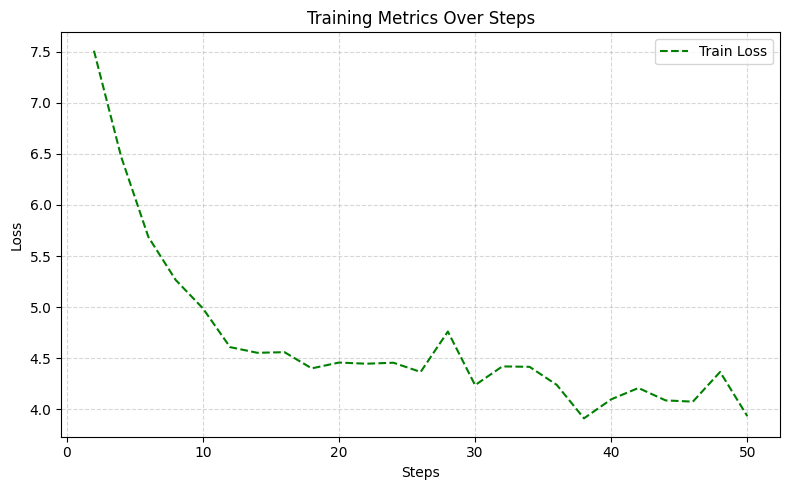

In [16]:
# 从训练保存的checkpoint文件里加载训练评估日志

import json
import pandas as pd
import matplotlib.pyplot as plt
import os

def analyze_trainer_logs(json_path, save_dir=None):
    # 1. 加载数据
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    df = pd.DataFrame(data['log_history'])
    
    # 2. 分离训练和评估数据
    # 训练行通常包含 'loss'，评估行包含 'eval_loss'
    train_df = df.dropna(subset=['loss']).copy()
    
    # 3. 打印简报
    print(f"{'Step':<10} | {'Epoch':<10} | {'Train Loss':<12}")
    print("-" * 52)
    
    # 合并数据查看（按 Step 对齐最近的记录）
    for _, row in train_df.iterrows():
        step = row['step']
        epoch = row['epoch']
        
        # 找到训练集中最接近该 step 的 train_loss
        matching_train = train_df[train_df['step'] <= step].iloc[-1] if not train_df.empty else None
        train_loss = matching_train['loss'] if matching_train is not None else "N/A"
        
        print(f"{int(step):<10} | {epoch:<10.2f} | {train_loss:<12.4f} ")

    # 4. 绘图
    fig, ax1 = plt.subplots(figsize=(8, 5))

    # 左轴：绘制 Loss
    ax1.set_xlabel('Steps')
    ax1.set_ylabel('Loss')
    ax1.plot(train_df['step'], train_df['loss'], label='Train Loss', color='green',linestyle='--')
    ax1.tick_params(axis='y')
    ax1.legend(loc='upper right')
    ax1.grid(True, which='both', linestyle='--', alpha=0.5)

    plt.title('Training Metrics Over Steps')
    fig.tight_layout()
    
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'training_analysis.png'))
        print(f"\n图表已保存至: {os.path.join(save_dir, 'training_analysis.png')}")
    
    plt.show()

# --- 使用示例 ---
# 替换为你最新的那个 checkpoint 文件夹下的 json 路径
json_path = './model_output/self_data_chatglm4_zhouyi_lora/checkpoint-50/trainer_state.json'
analyze_trainer_logs(json_path, save_dir="./")